In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time
from shapely.geometry import Polygon, Point

import geopandas as gpd

from src.text_processing_functions import *
from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

In [3]:
# #Select one report 
# # all_reports = pd.read_csv(DATA_OUT_LLMS+'labelled_reports_response_llm_levels_haz_types_subtypes_impacts_geocoding.csv')
# file_path = DATA_IN_JSONS +'filtered_report_types_nat_hazards_summary-header.json'#'nathaz_ifrc_reports_info_processed.json'

# # Open and read the JSON file
# with open(file_path, 'r') as json_file:
#     ifrc_reports_processed = json.load(json_file)
# all_reports = pd.DataFrame(ifrc_reports_processed)
# all_reports = all_reports.rename({"location" : "country"}, axis=1)
# # all_reports = all_reports.rename({"disasterTypeReclassified" : "hazardType"}, axis=1)

# Convert location to polygons

In [13]:
#Post process files 
# df_labelled = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_labelled_reports_impacts_all.csv', encoding='utf-8')
# df_llm = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_llm_response_impact_labelled_reports_test_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct.csv', encoding='utf-8')
# df_llm = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_llm_response_impact_labelled_reports_test_multiprompt_16rep_meta-llama_llama-4-scout-17b-16e-instruct.csv', encoding='utf-8')

df_labelled = pd.read_csv(DATA_LABELLED + 'labelled_reports_impact_laura_18-08-25.csv', encoding='utf-8')


In [14]:
df_labelled.head()

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,appealCode
0,2024-08-06,Residential Buildings,55.0,houses damaged,exact,NaN,NaN,['Barbados was spared a direct hit from the hu...,['Barbados'],NaN,2024.0,6.0,25.0,NaN,NaN,NaN,['Tropical storm'],MDRS2001
1,2024-08-06,Agricultural Infrastructure,200.0,vessels,exact,NaN,NaN,['Barbados was spared a direct hit from the hu...,['Barbados'],NaN,2024.0,6.0,25.0,NaN,NaN,NaN,['Tropical storm'],MDRS2001
2,2024-08-06,AOther Economic and Livelihood Impacts,NaN,NaN,NaN,NaN,NaN,['Barbados was spared a direct hit from the hu...,['Barbados'],NaN,2024.0,6.0,25.0,NaN,NaN,NaN,['Tropical storm'],MDRS2001
3,2024-08-06,Displaced People,NaN,people,approx,1600.0,NaN,"['On July 1, the hurricane made landfall in Gr...",['Grenada'],NaN,2024.0,7.0,1.0,NaN,NaN,NaN,['Tropical storm'],MDRS2001
4,2024-08-06,Other Infrastructure impact,98.0,% buildings damaged,exact,NaN,NaN,"['On July 1, the hurricane made landfall in Gr...",['Grenada'],"['Carriacou islands', 'Petit Martinique island']",2024.0,7.0,1.0,NaN,NaN,NaN,['Tropical storm'],MDRS2001


In [8]:
similarity_th=0.2
similarity_polygon = 0.6
print_info=False
save_path=False
res_savename=False
split_lowest_levels = True

#For the llm version 
save_path = DATA_PATH + 'results_proc/'
res_savename = 'post_processed_llm_response_impact_labelled_reports_test_multiprompt_16rep_meta-llama_llama-4-scout-17b-16e-instruct'
df_llm_geo_split = geocode_df_to_polygon(df_llm, similarity_th=0.2, split_lowest_levels=split_lowest_levels, print_info=print_info, save_path=save_path, res_savename=res_savename)

#Without splitting over highest admin levels 
split_lowest_levels = False
df_llm_geo = geocode_df_to_polygon(df_llm, similarity_th=0.2, split_lowest_levels=split_lowest_levels, print_info=print_info, save_path=save_path, res_savename=res_savename)

c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\geocoding.py:558: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)
c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\geocoding.py:558: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)
c:\Users\lhasbini\ownCloud\Documents\Thèse\program

In [15]:
##### For the labelled version 

## Splitting the highest levels
split_lowest_levels = True 
# save_path = DATA_PATH + 'results_proc/'
# res_savename = 'post_processed_labelled_reports_impacts_all'
save_path = DATA_LABELLED
res_savename = 'labelled_reports_impact_laura_18-08-25'
# df_labelled_geo_split = geocode_df_to_polygon(df_labelled, similarity_th=0.2, split_lowest_levels=split_lowest_levels, print_info=print_info, save_path=save_path, res_savename=res_savename)

## Withou splitting the highest levels 
split_lowest_levels = False
df_labelled_geo = geocode_df_to_polygon(df_labelled, similarity_th=0.2, split_lowest_levels=split_lowest_levels, print_info=print_info, save_path=save_path, res_savename=res_savename)

c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\geocoding.py:558: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)
c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\geocoding.py:558: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)


In [10]:
split_lowest_levels = True
save_df = df_labelled_geo.copy()
columns_list_to_str = ['location', 'locationOsm', 'country', 'gaul0_code', 'gaul1_code', 'gaul2_code']
for col in columns_list_to_str : 
    save_df[col] = save_df[col].apply(lambda x: str(x) if isinstance(x, list) else x)  

save_gdf = gpd.GeoDataFrame(save_df, geometry='locationPolygon')
save_gdf = save_gdf.set_crs("EPSG:4326", allow_override=True)
try:
    if split_lowest_levels : 
        suffix = "_geo_split_lowest"
    else : 
        suffix = "_geo"
    save_gdf.to_file(f"{save_path}{res_savename}{suffix}.gpkg",
                    layer="multipolygons", driver="GPKG")
except Exception as e:
    print(f"[GeoPackage Save Error] {e}")

In [7]:
df_labelled_geo.head()

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,impactsAnnotation,country,location,...,unit_type,gaul0_code,gaul1_code,gaul2_code,locationPolygon,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationGaul
0,2019-07-19,Affected People,2176519.0,people,exact,NaN,NaN,['DREF operation n MDRBD022 Glide n FL-2019-00...,[Bangladesh],[],...,other,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]
1,2019-07-19,Affected People,1000000.0,people,approx,NaN,NaN,['While the monsoon season normally brings ann...,"[Nepal, India]",[],...,other,[258.0],[None],[None],MULTIPOLYGON (((73.02247155000003 8.2743594420...,ADM_0,1,0,[Nepal],[Nepal]
2,2019-07-19,Affected People,2100000.0,people,approx,2100000.0,NaN,['According to National disaster response coor...,[Bangladesh],"['Kurigram district', 'Gaibandha district', 'L...",...,other,[229.0],"[2476, 2478, 2477, None, 2473, 2479, 2474]",[None],MULTIPOLYGON (((89.06381269600007 21.841457424...,ADM_0,4,35,"[Kurigram District, Gaibandha District, Bangla...","[Mymensingh, Rangpur, Rajshahi, Bangladesh, Ch..."
3,2019-07-19,Affected People,NaN,NaN,approx,2100000.0,NaN,['According to National disaster response coor...,[Bangladesh],"['Kurigram district', 'Gaibandha district', 'L...",...,other,[229.0],"[2476, 2478, 2477, 2473, 2479, 2474]",[None],MULTIPOLYGON (((90.98868129990223 22.044713599...,ADM_1,0,35,"[Kurigram District, Gaibandha District, Chatto...","[Mymensingh, Rangpur, Rajshahi, Chittagong, Sy..."
4,2019-07-19,Residential Buildings,10000.0,homes,approx,NaN,NaN,['According to National disaster response coor...,[Bangladesh],"['Kurigram district', 'Gaibandha district', 'L...",...,other,[229.0],"[2476, 2478, 2477, None, 2473, 2479, 2474]",[None],MULTIPOLYGON (((89.06381269600007 21.841457424...,ADM_0,5,32,"[Kurigram District, Gaibandha District, Bangla...","[Mymensingh, Rangpur, Rajshahi, Bangladesh, Ch..."


## Quality of the geocoding

- For each appealCode : 
    - Number of unique locations found 
    - Over this locations, split between the ones geocoded and the level at which they have been geocoded (ADM_0/ADM_1/ADM_2)

In [29]:
df_llm_geo.head()

,impactSubtype,impactValue,impactUnit,impactValuePrecision,country,location,startYear,startMonth,startDay,endYear,...,unit_type,gaul0_code,gaul1_code,gaul2_code,locationPolygon,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationGaul
0,Residential Buildings,205368.00,homes,exact,[Bangladesh],[19 affected districts],2020.0,5.0,20.0,NaN,...,other,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]
1,Residential Buildings,55767.00,homes,exact,[Bangladesh],[19 affected districts],2020.0,5.0,20.0,NaN,...,other,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]
2,Crop Production and Forestry,320.37,km**2 of crop production and forestry,exact,[Bangladesh],[19 affected districts],2020.0,5.0,20.0,NaN,...,km**2,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]
3,"Water, Sanitation, and Hygiene Infrastructure",18235.00,"water, sanitation and hygiene facilities",exact,[Bangladesh],[19 affected districts],2020.0,5.0,20.0,NaN,...,other,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]
4,Other Transportation Infrastructure,440.00,km of roads,exact,[Bangladesh],[19 affected districts],2020.0,5.0,20.0,NaN,...,km,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]


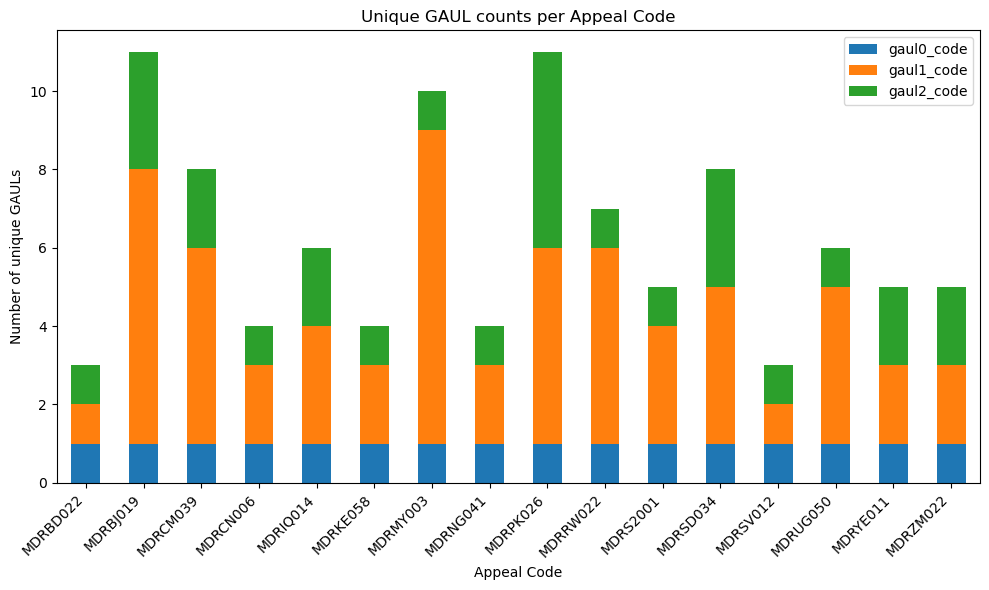

In [31]:
def count_unique_lists(series):
    all_elements = set()
    for lst in series:
        if isinstance(lst, list):
            all_elements.update(lst)
    return len(all_elements)

# Prepare the data
plot_data = df_llm_geo.groupby('appealCode').agg({
    'gaul0_code': count_unique_lists,
    'gaul1_code': count_unique_lists,
    'gaul2_code': count_unique_lists
})

# Plot
ax = plot_data.plot(kind='bar', stacked=True, figsize=(10,6))
ax.set_ylabel("Number of unique GAULs")
ax.set_xlabel("Appeal Code")
ax.set_title("Unique GAUL counts per Appeal Code")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

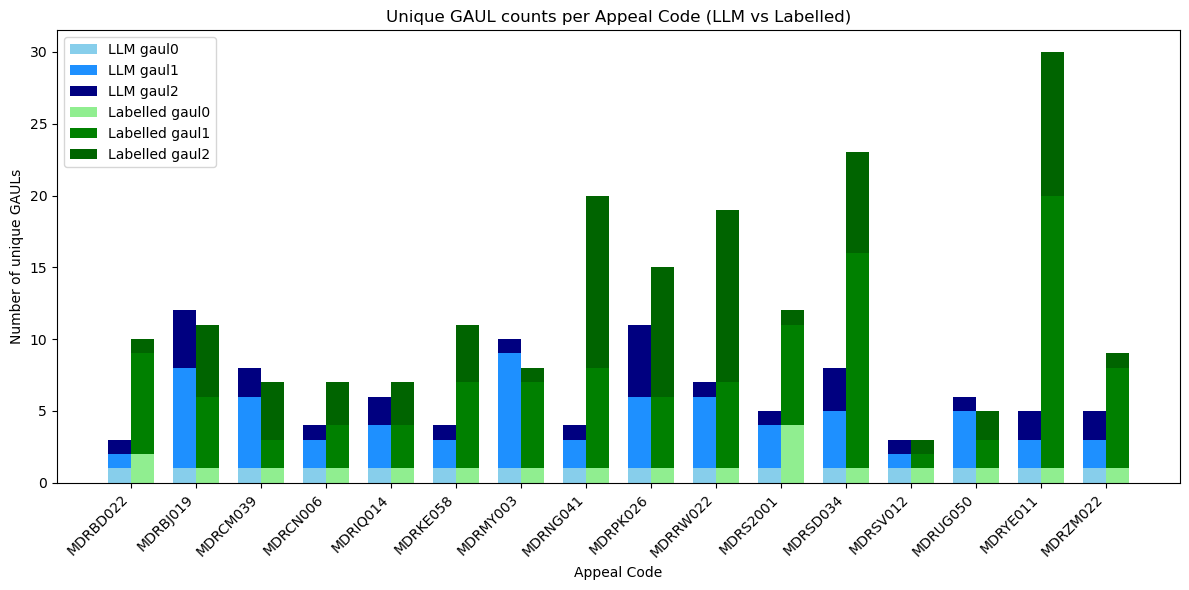

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# Function to count unique elements in lists per group
def count_unique_lists(series):
    all_elements = set()
    for lst in series:
        if isinstance(lst, list):
            all_elements.update(lst)
    return len(all_elements)

# Aggregate data for both datasets
plot_data_llm = df_llm_geo.groupby('appealCode').agg({
    'gaul0_code': count_unique_lists,
    'gaul1_code': count_unique_lists,
    'gaul2_code': count_unique_lists
})

plot_data_labelled = df_labelled_geo.groupby('appealCode').agg({
    'gaul0_code': count_unique_lists,
    'gaul1_code': count_unique_lists,
    'gaul2_code': count_unique_lists
})

# Make sure both have the same appealCodes in the same order
all_codes = sorted(set(plot_data_llm.index) | set(plot_data_labelled.index))
plot_data_llm = plot_data_llm.reindex(all_codes, fill_value=0)
plot_data_labelled = plot_data_labelled.reindex(all_codes, fill_value=0)

# Set bar positions
x = np.arange(len(all_codes))
width = 0.35  # width of each bar

# Plot
fig, ax = plt.subplots(figsize=(12,6))

# LLM bars
ax.bar(x - width/2, plot_data_llm['gaul0_code'], width, label='LLM gaul0', color='skyblue', bottom=0)
ax.bar(x - width/2, plot_data_llm['gaul1_code'], width, label='LLM gaul1', color='dodgerblue', bottom=plot_data_llm['gaul0_code'])
bottom_llm = plot_data_llm['gaul0_code'] + plot_data_llm['gaul1_code']
ax.bar(x - width/2, plot_data_llm['gaul2_code'], width, label='LLM gaul2', color='navy', bottom=bottom_llm)

# Labelled bars
ax.bar(x + width/2, plot_data_labelled['gaul0_code'], width, label='Labelled gaul0', color='lightgreen', bottom=0)
ax.bar(x + width/2, plot_data_labelled['gaul1_code'], width, label='Labelled gaul1', color='green', bottom=plot_data_labelled['gaul0_code'])
bottom_labelled = plot_data_labelled['gaul0_code'] + plot_data_labelled['gaul1_code']
ax.bar(x + width/2, plot_data_labelled['gaul2_code'], width, label='Labelled gaul2', color='darkgreen', bottom=bottom_labelled)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(all_codes, rotation=45, ha='right')
ax.set_ylabel("Number of unique GAULs")
ax.set_xlabel("Appeal Code")
ax.set_title("Unique GAUL counts per Appeal Code (LLM vs Labelled)")
ax.legend(loc='upper left')
plt.tight_layout()
fig.savefig(DATA_FIGURE+'counts_unique_loc_admin_appealCode_llm-labelled.png', dpi=300, bbox_inches='tight', transparent=True)

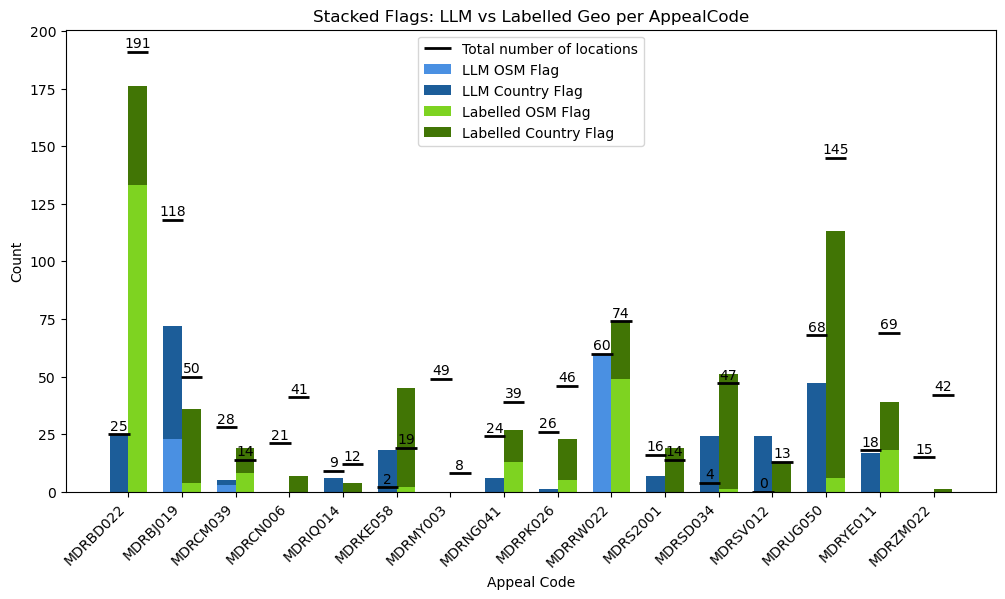

In [84]:
# Compute number of locations per row
for df in [df_llm_geo_split, df_labelled_geo]:
    df['num_locations'] = df['location'].apply(len)

# Group by appealCode
grouped_llm = df_llm_geo_split.groupby('appealCode').agg({
    'num_locations': 'sum',
    'geocoding_osm_flag': 'sum',
    'geocoding_country_flag': 'sum'
}).reset_index()

grouped_labelled = df_labelled_geo.groupby('appealCode').agg({
    'num_locations': 'sum',
    'geocoding_osm_flag': 'sum',
    'geocoding_country_flag': 'sum'
}).reset_index()

# Set bar width and positions
bar_width = 0.35
x = np.arange(len(grouped_llm['appealCode']))

fig, ax = plt.subplots(figsize=(12,6))

# Colors
llm_colors = ['#4A90E2', '#1C5D99']       # Light blue, dark blue
labelled_colors = ['#7ED321', '#417505']  # Light green, dark green

# LLM bars
ax.bar(x - bar_width/2, grouped_llm['geocoding_osm_flag'], bar_width, color=llm_colors[0], label='LLM OSM Flag')
ax.bar(x - bar_width/2, grouped_llm['geocoding_country_flag'], bar_width, 
       bottom=grouped_llm['geocoding_osm_flag'], color=llm_colors[1], label='LLM Country Flag')

# Labelled bars
ax.bar(x + bar_width/2, grouped_labelled['geocoding_osm_flag'], bar_width, color=labelled_colors[0], label='Labelled OSM Flag')
ax.bar(x + bar_width/2, grouped_labelled['geocoding_country_flag'], bar_width, 
       bottom=grouped_labelled['geocoding_osm_flag'], color=labelled_colors[1], label='Labelled Country Flag')

# Plot total reports as lines
for i in range(len(x)):
    ax.hlines(y=grouped_llm['num_locations'][i], xmin=i - bar_width/2 - 0.2, xmax=i - bar_width/2 + 0.2, 
              color='black', lw=2, label='Total number of locations' if i==0 else "")
    ax.text(i - bar_width/2, grouped_llm['num_locations'][i] + 0.5, str(grouped_llm['num_locations'][i]), 
            ha='center', va='bottom', fontsize=10)
    
    ax.hlines(y=grouped_labelled['num_locations'][i], xmin=i + bar_width/2 - 0.2, xmax=i + bar_width/2 + 0.2, 
              color='black', lw=2)
    ax.text(i + bar_width/2, grouped_labelled['num_locations'][i] + 0.5, str(grouped_labelled['num_locations'][i]), 
            ha='center', va='bottom', fontsize=10)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(grouped_llm['appealCode'], rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_xlabel('Appeal Code')
ax.set_title('Stacked Flags: LLM vs Labelled Geo per AppealCode')
ax.legend()
fig.savefig(DATA_FIGURE+'counts_flags_appealCode_llm-labelled.png', dpi=300, bbox_inches='tight', transparent=True)
